
# ABC Bank News Classification: Combined Analysis of Extract N-Grams vs Feature Hashing

This notebook combines the scored outputs from two text feature engineering pipelines:

- **Extract N-Grams + Multiclass Boosted Decision Tree**
- **Feature Hashing + Multiclass Boosted Decision Tree**

The goal is to compare both approaches on the same scored dataset and turn the results into **business-usable insights**.



## What this notebook covers

1. Load and align both scored datasets
2. Validate whether both methods scored the same records in the same order
3. Compare accuracy, agreement, and class-level performance
4. Compare confidence and feature-space behavior
5. Visualize class distributions and confusion matrices
6. Use the **n-gram model** to surface interpretable class keywords
7. Summarize what these results mean for business use


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

ngram_path = Path('../datasets/extract_n-grams-scored_data.csv')
hash_path = Path('../datasets/feature_hashing-scored_data.csv')

ngram_df = pd.read_csv(ngram_path)
hash_df = pd.read_csv(hash_path)

print('N-gram scored data shape   :', ngram_df.shape)
print('Hashing scored data shape  :', hash_df.shape)


N-gram scored data shape   : (1500, 703)
Hashing scored data shape  : (1500, 1034)


In [2]:

# Identify key columns
key_cols = ['category', 'news', 'Preprocessed news']
prob_cols = [c for c in ngram_df.columns if c.startswith('Scored Probabilities_')]
ngram_feature_cols = [c for c in ngram_df.columns if c.startswith('Preprocessed news.[')]
hash_feature_cols = [c for c in hash_df.columns if c.startswith('Preprocessed news_HashingFeature.')]

print('Key columns               :', key_cols)
print('Probability columns       :', prob_cols)
print('N-gram feature count      :', len(ngram_feature_cols))
print('Hashing feature count     :', len(hash_feature_cols))


Key columns               : ['category', 'news', 'Preprocessed news']
Probability columns       : ['Scored Probabilities_car_loan', 'Scored Probabilities_credit_card', 'Scored Probabilities_fixed_deposit', 'Scored Probabilities_home_loan', 'Scored Probabilities_insurance', 'Scored Probabilities_mutual_funds']
N-gram feature count      : 693
Hashing feature count     : 1024


## 1) Alignment check

In [3]:

# Make sure both datasets refer to the same rows
aligned = (ngram_df[key_cols] == hash_df[key_cols]).all().all()
print('Row alignment across both scored datasets:', aligned)

if not aligned:
    raise ValueError('The two scored datasets are not aligned on the common key columns.')


Row alignment across both scored datasets: True


## 2) Build a combined comparison dataset

In [4]:

combined = ngram_df[key_cols].copy()
combined['true_label'] = ngram_df['category']
combined['pred_ngram'] = ngram_df['Scored Labels']
combined['pred_hash'] = hash_df['Scored Labels']
combined['agree'] = combined['pred_ngram'] == combined['pred_hash']
combined['correct_ngram'] = combined['true_label'] == combined['pred_ngram']
combined['correct_hash'] = combined['true_label'] == combined['pred_hash']

# Bring in scored probabilities with method suffixes
for col in prob_cols:
    combined[col + '_ngram'] = ngram_df[col]
    combined[col + '_hash'] = hash_df[col]

# Confidence metrics
combined['max_prob_ngram'] = ngram_df[prob_cols].max(axis=1)
combined['max_prob_hash'] = hash_df[prob_cols].max(axis=1)
combined['margin_ngram'] = ngram_df[prob_cols].apply(lambda r: r.nlargest(2).iloc[0] - r.nlargest(2).iloc[1], axis=1)
combined['margin_hash'] = hash_df[prob_cols].apply(lambda r: r.nlargest(2).iloc[0] - r.nlargest(2).iloc[1], axis=1)
combined['active_ngram_features'] = (ngram_df[ngram_feature_cols] != 0).sum(axis=1)
combined['active_hash_features'] = (hash_df[hash_feature_cols] != 0).sum(axis=1)

combined.head()


,category,news,Preprocessed news,true_label,pred_ngram,pred_hash,agree,correct_ngram,correct_hash,Scored Probabilities_car_loan_ngram,...,Scored Probabilities_insurance_ngram,Scored Probabilities_insurance_hash,Scored Probabilities_mutual_funds_ngram,Scored Probabilities_mutual_funds_hash,max_prob_ngram,max_prob_hash,margin_ngram,margin_hash,active_ngram_features,active_hash_features
0,mutual_funds,Customers are increasingly focused on market-l...,customer increasingly focus market link return...,mutual_funds,mutual_funds,mutual_funds,True,True,True,6.384103e-07,...,6.384103e-07,6.384103e-07,9.999968e-01,9.999968e-01,0.999997,0.999997,0.999996,0.999996,40,107
1,credit_card,Recent developments in credit card interest ra...,recent development credit card interest rate c...,credit_card,credit_card,credit_card,True,True,True,6.384103e-07,...,6.384103e-07,6.384103e-07,6.384103e-07,6.384103e-07,0.999997,0.999997,0.999996,0.999996,38,103
2,car_loan,Analysts expect car loan approval to play a cr...,analyst expect car loan approval play crucial ...,car_loan,car_loan,car_loan,True,True,True,9.999968e-01,...,6.384103e-07,6.384103e-07,6.384103e-07,6.384103e-07,0.999997,0.999997,0.999996,0.999996,42,110
3,car_loan,Analysts expect auto financing to play a cruci...,analyst expect auto financing play crucial rol...,car_loan,car_loan,car_loan,True,True,True,9.999968e-01,...,6.384103e-07,6.384103e-07,6.384103e-07,6.384103e-07,0.999997,0.999997,0.999996,0.999996,37,106
4,home_loan,"According to recent reports, refinancing optio...",accord recent report refinance option signific...,home_loan,home_loan,home_loan,True,True,True,6.384103e-07,...,6.384103e-07,6.384103e-07,6.384103e-07,6.384103e-07,0.999997,0.999997,0.999996,0.999996,36,109


In [5]:

# Optional: save the merged comparison file for later use
combined.to_csv('abc_news_combined_scored_comparison.csv', index=False)
print('Saved: abc_news_combined_scored_comparison.csv')


Saved: abc_news_combined_scored_comparison.csv


## 3) High-level score comparison

In [6]:

summary = pd.DataFrame({
    'Method': ['Extract N-Grams', 'Feature Hashing'],
    'Rows': [len(combined), len(combined)],
    'Accuracy': [combined['correct_ngram'].mean(), combined['correct_hash'].mean()],
    'Prediction Agreement': [combined['agree'].mean(), combined['agree'].mean()],
    'Mean Max Probability': [combined['max_prob_ngram'].mean(), combined['max_prob_hash'].mean()],
    'Mean Probability Margin': [combined['margin_ngram'].mean(), combined['margin_hash'].mean()],
    'Avg Active Features per Record': [combined['active_ngram_features'].mean(), combined['active_hash_features'].mean()],
    'Feature Count': [len(ngram_feature_cols), len(hash_feature_cols)]
})
summary


,Method,Rows,Accuracy,Prediction Agreement,Mean Max Probability,Mean Probability Margin,Avg Active Features per Record,Feature Count
0,Extract N-Grams,1500,1.0,1.0,0.999997,0.999996,36.710667,693
1,Feature Hashing,1500,1.0,1.0,0.999997,0.999996,106.631333,1024



### Quick interpretation

- **Accuracy** shows how often the predicted label matched the true category.
- **Prediction agreement** shows how often both pipelines produced the same class.
- **Mean max probability** and **margin** indicate model confidence.
- **Avg active features** tells you how many non-zero features each record activates on average.


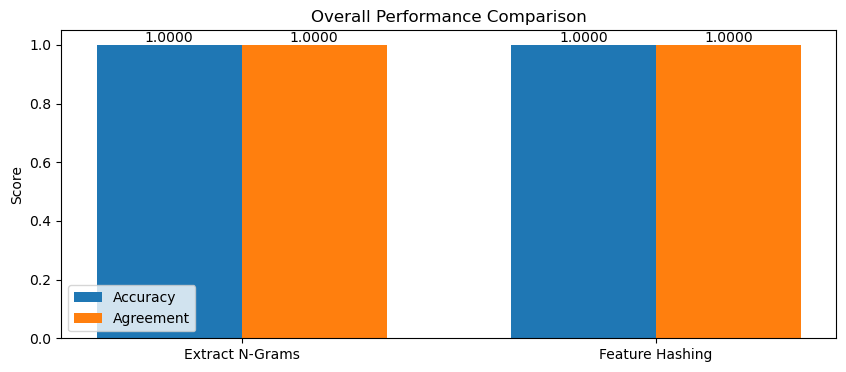

In [7]:

fig, ax = plt.subplots(figsize=(10, 4))
bar_positions = np.arange(len(summary))
width = 0.35

ax.bar(bar_positions - width/2, summary['Accuracy'], width=width, label='Accuracy')
ax.bar(bar_positions + width/2, summary['Prediction Agreement'], width=width, label='Agreement')
ax.set_xticks(bar_positions)
ax.set_xticklabels(summary['Method'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Overall Performance Comparison')
ax.legend()
for i, val in enumerate(summary['Accuracy']):
    ax.text(i - width/2, val + 0.01, f'{val:.4f}', ha='center')
for i, val in enumerate(summary['Prediction Agreement']):
    ax.text(i + width/2, val + 0.01, f'{val:.4f}', ha='center')
plt.show()


## 4) Class balance and predicted label balance

In [8]:

label_order = sorted(combined['true_label'].unique())
true_counts = combined['true_label'].value_counts().reindex(label_order)
pred_ngram_counts = combined['pred_ngram'].value_counts().reindex(label_order)
pred_hash_counts = combined['pred_hash'].value_counts().reindex(label_order)

class_balance = pd.DataFrame({
    'True Count': true_counts,
    'Predicted (N-Gram)': pred_ngram_counts,
    'Predicted (Hashing)': pred_hash_counts
})
class_balance


,True Count,Predicted (N-Gram),Predicted (Hashing)
car_loan,250,250,250
credit_card,250,250,250
fixed_deposit,250,250,250
home_loan,250,250,250
insurance,250,250,250
mutual_funds,250,250,250


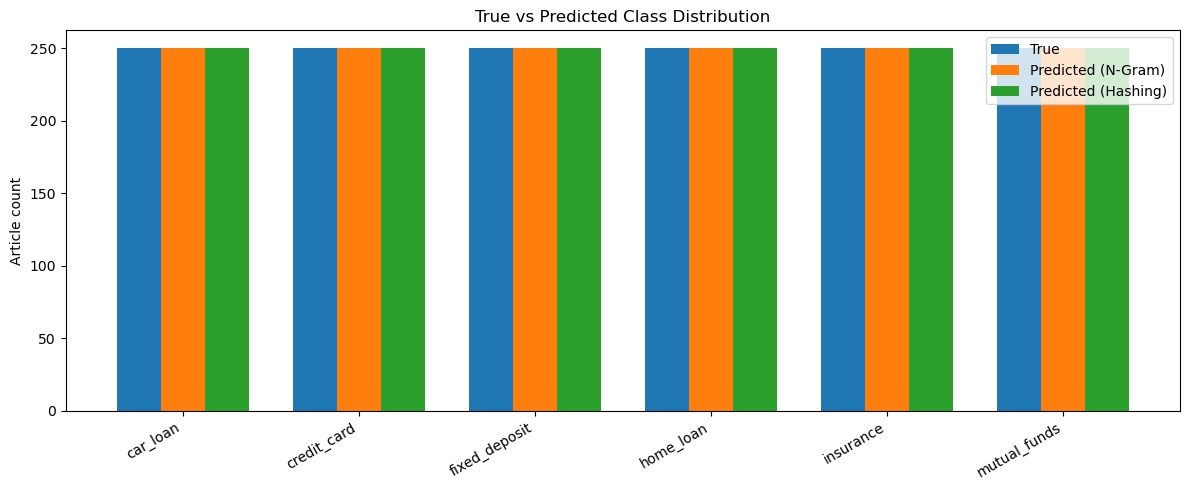

In [9]:

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(label_order))
width = 0.25
ax.bar(x - width, true_counts.values, width=width, label='True')
ax.bar(x, pred_ngram_counts.values, width=width, label='Predicted (N-Gram)')
ax.bar(x + width, pred_hash_counts.values, width=width, label='Predicted (Hashing)')
ax.set_xticks(x)
ax.set_xticklabels(label_order, rotation=30, ha='right')
ax.set_ylabel('Article count')
ax.set_title('True vs Predicted Class Distribution')
ax.legend()
plt.tight_layout()
plt.show()


## 5) Confusion matrices

C:\Users\Edwin\AppData\Local\Temp\ipykernel_21992\2071506148.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


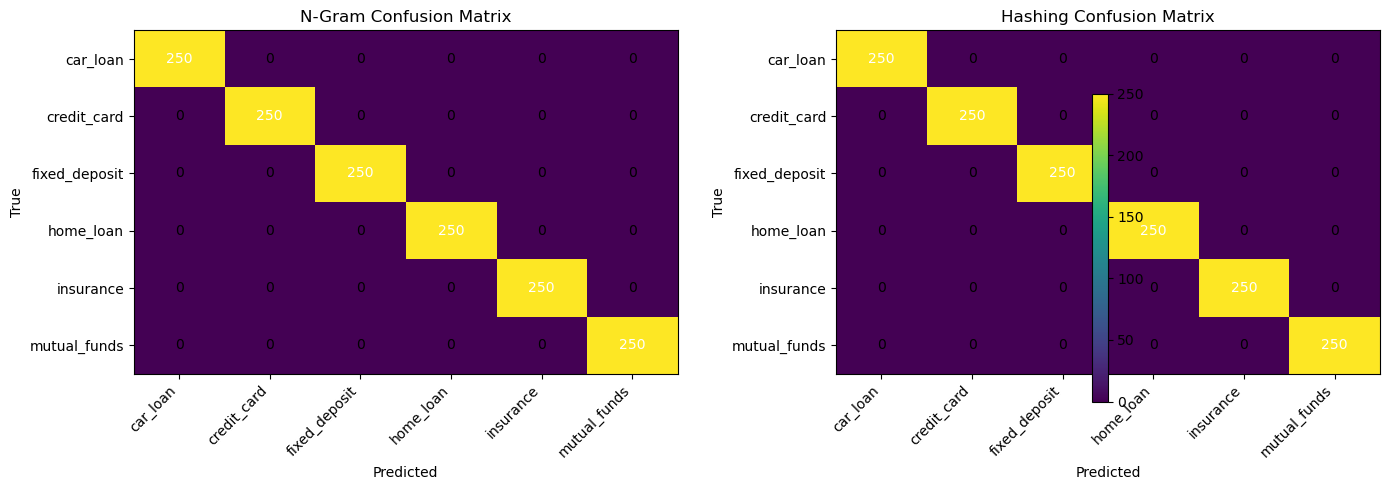

In [10]:

cm_ngram = pd.crosstab(combined['true_label'], combined['pred_ngram']).reindex(index=label_order, columns=label_order, fill_value=0)
cm_hash = pd.crosstab(combined['true_label'], combined['pred_hash']).reindex(index=label_order, columns=label_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(axes, [cm_ngram, cm_hash], ['N-Gram Confusion Matrix', 'Hashing Confusion Matrix']):
    im = ax.imshow(cm.values, aspect='auto')
    ax.set_xticks(np.arange(len(label_order)))
    ax.set_yticks(np.arange(len(label_order)))
    ax.set_xticklabels(label_order, rotation=45, ha='right')
    ax.set_yticklabels(label_order)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm.iloc[i, j], ha='center', va='center', color='white' if cm.iloc[i, j] > cm.values.max()/2 else 'black')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()


## 6) Agreement and confidence

In [11]:

agreement_rate = combined['agree'].mean()
print(f'Prediction agreement between methods: {agreement_rate:.4f}')
print('Disagreement count:', (~combined['agree']).sum())

confidence_summary = pd.DataFrame({
    'Metric': ['Mean Max Probability', 'Min Max Probability', 'Mean Margin', 'Min Margin'],
    'N-Gram': [combined['max_prob_ngram'].mean(), combined['max_prob_ngram'].min(), combined['margin_ngram'].mean(), combined['margin_ngram'].min()],
    'Hashing': [combined['max_prob_hash'].mean(), combined['max_prob_hash'].min(), combined['margin_hash'].mean(), combined['margin_hash'].min()]
})
confidence_summary


Prediction agreement between methods: 1.0000
Disagreement count: 0


,Metric,N-Gram,Hashing
0,Mean Max Probability,0.999997,0.999997
1,Min Max Probability,0.999997,0.999997
2,Mean Margin,0.999996,0.999996
3,Min Margin,0.999996,0.999996


ValueError: Too many bins for data range. Cannot create 20 finite-sized bins.

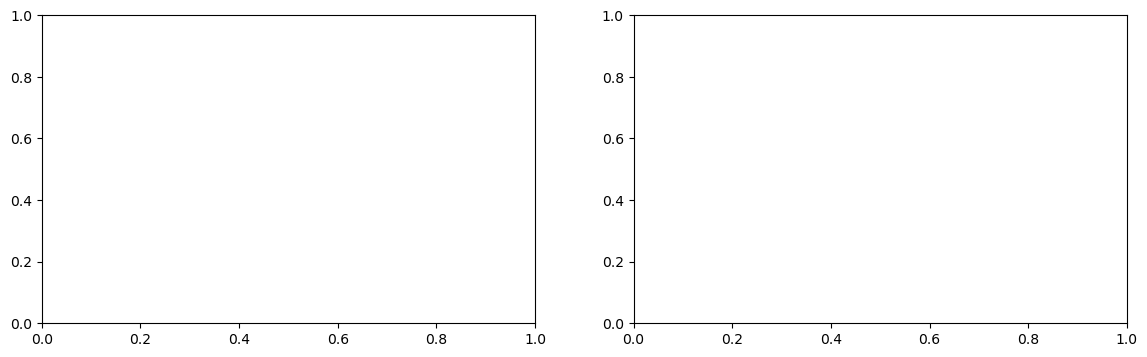

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(combined['max_prob_ngram'], bins=20, alpha=0.7, label='N-Gram')
axes[0].hist(combined['max_prob_hash'], bins=20, alpha=0.7, label='Hashing')
axes[0].set_title('Distribution of Max Predicted Probability')
axes[0].set_xlabel('Max predicted probability')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(combined['margin_ngram'], bins=20, alpha=0.7, label='N-Gram')
axes[1].hist(combined['margin_hash'], bins=20, alpha=0.7, label='Hashing')
axes[1].set_title('Distribution of Prediction Margin (Top1 - Top2)')
axes[1].set_xlabel('Margin')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.show()



### Interpretation

- A **high max probability** means the model is very sure about its top class.
- A **high margin** means the winning class is far ahead of the second-best class.
- If both methods have almost identical confidence distributions, the feature engineering change did not materially change the scored output.


## 7) Feature-space comparison

In [13]:

feature_activity = combined[['true_label', 'active_ngram_features', 'active_hash_features']].copy()
feature_activity.head()


,true_label,active_ngram_features,active_hash_features
0,mutual_funds,40,107
1,credit_card,38,103
2,car_loan,42,110
3,car_loan,37,106
4,home_loan,36,109


In [14]:

activity_by_class = feature_activity.groupby('true_label')[['active_ngram_features', 'active_hash_features']].mean().reindex(label_order)
activity_by_class


,active_ngram_features,active_hash_features
true_label,,
car_loan,40.392,109.520
credit_card,36.936,105.256
fixed_deposit,34.344,107.184
home_loan,35.452,105.188
insurance,34.720,106.616
mutual_funds,38.420,106.024


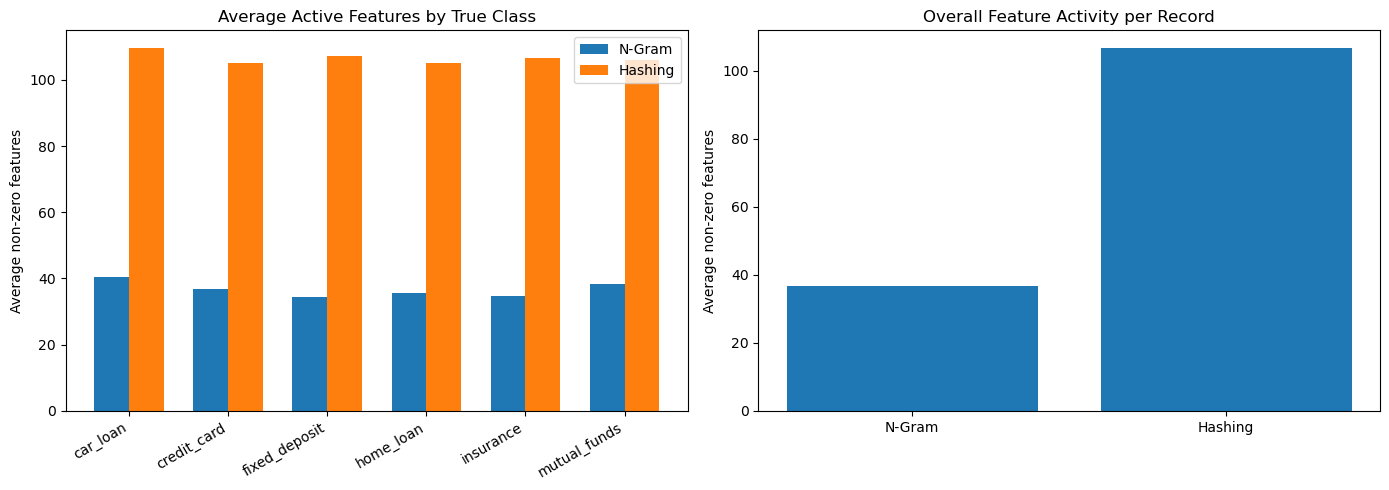

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average active features by class
x = np.arange(len(label_order))
width = 0.35
axes[0].bar(x - width/2, activity_by_class['active_ngram_features'], width=width, label='N-Gram')
axes[0].bar(x + width/2, activity_by_class['active_hash_features'], width=width, label='Hashing')
axes[0].set_xticks(x)
axes[0].set_xticklabels(label_order, rotation=30, ha='right')
axes[0].set_ylabel('Average non-zero features')
axes[0].set_title('Average Active Features by True Class')
axes[0].legend()

# Overall average active features
axes[1].bar(['N-Gram', 'Hashing'], [combined['active_ngram_features'].mean(), combined['active_hash_features'].mean()])
axes[1].set_ylabel('Average non-zero features')
axes[1].set_title('Overall Feature Activity per Record')

plt.tight_layout()
plt.show()



### Interpretation

- **N-grams** produce fewer active features per record, but each feature is interpretable as a token or phrase.
- **Feature hashing** produces more active buckets per record, but those buckets are not human-readable.
- If performance is identical, the business choice becomes **interpretability vs compact fixed-size representation**.


## 8) Top interpretable n-grams per class

In [16]:

# Mean n-gram activation by class
class_ngram_means = ngram_df.groupby('category')[ngram_feature_cols].mean().reindex(label_order)

# Show top features in tabular form
rows = []
for label in label_order:
    top_feats = class_ngram_means.loc[label].sort_values(ascending=False).head(10)
    for feat, score in top_feats.items():
        rows.append({'Class': label, 'N-Gram Feature': feat.replace('Preprocessed news.[', '').replace(']', ''), 'Mean Weight': score})

top_ngram_table = pd.DataFrame(rows)
display(top_ngram_table.groupby('Class').head(10))


,Class,N-Gram Feature,Mean Weight
0,car_loan,car,0.506183
1,car_loan,car_loan,0.414273
2,car_loan,loan,0.340229
3,car_loan,auto,0.110791
4,car_loan,vehicle,0.107076
5,car_loan,financing,0.104889
6,car_loan,auto_loan,0.068784
7,car_loan,loan_deal,0.068784
8,car_loan,deal,0.068784
9,car_loan,auto_financing,0.067569


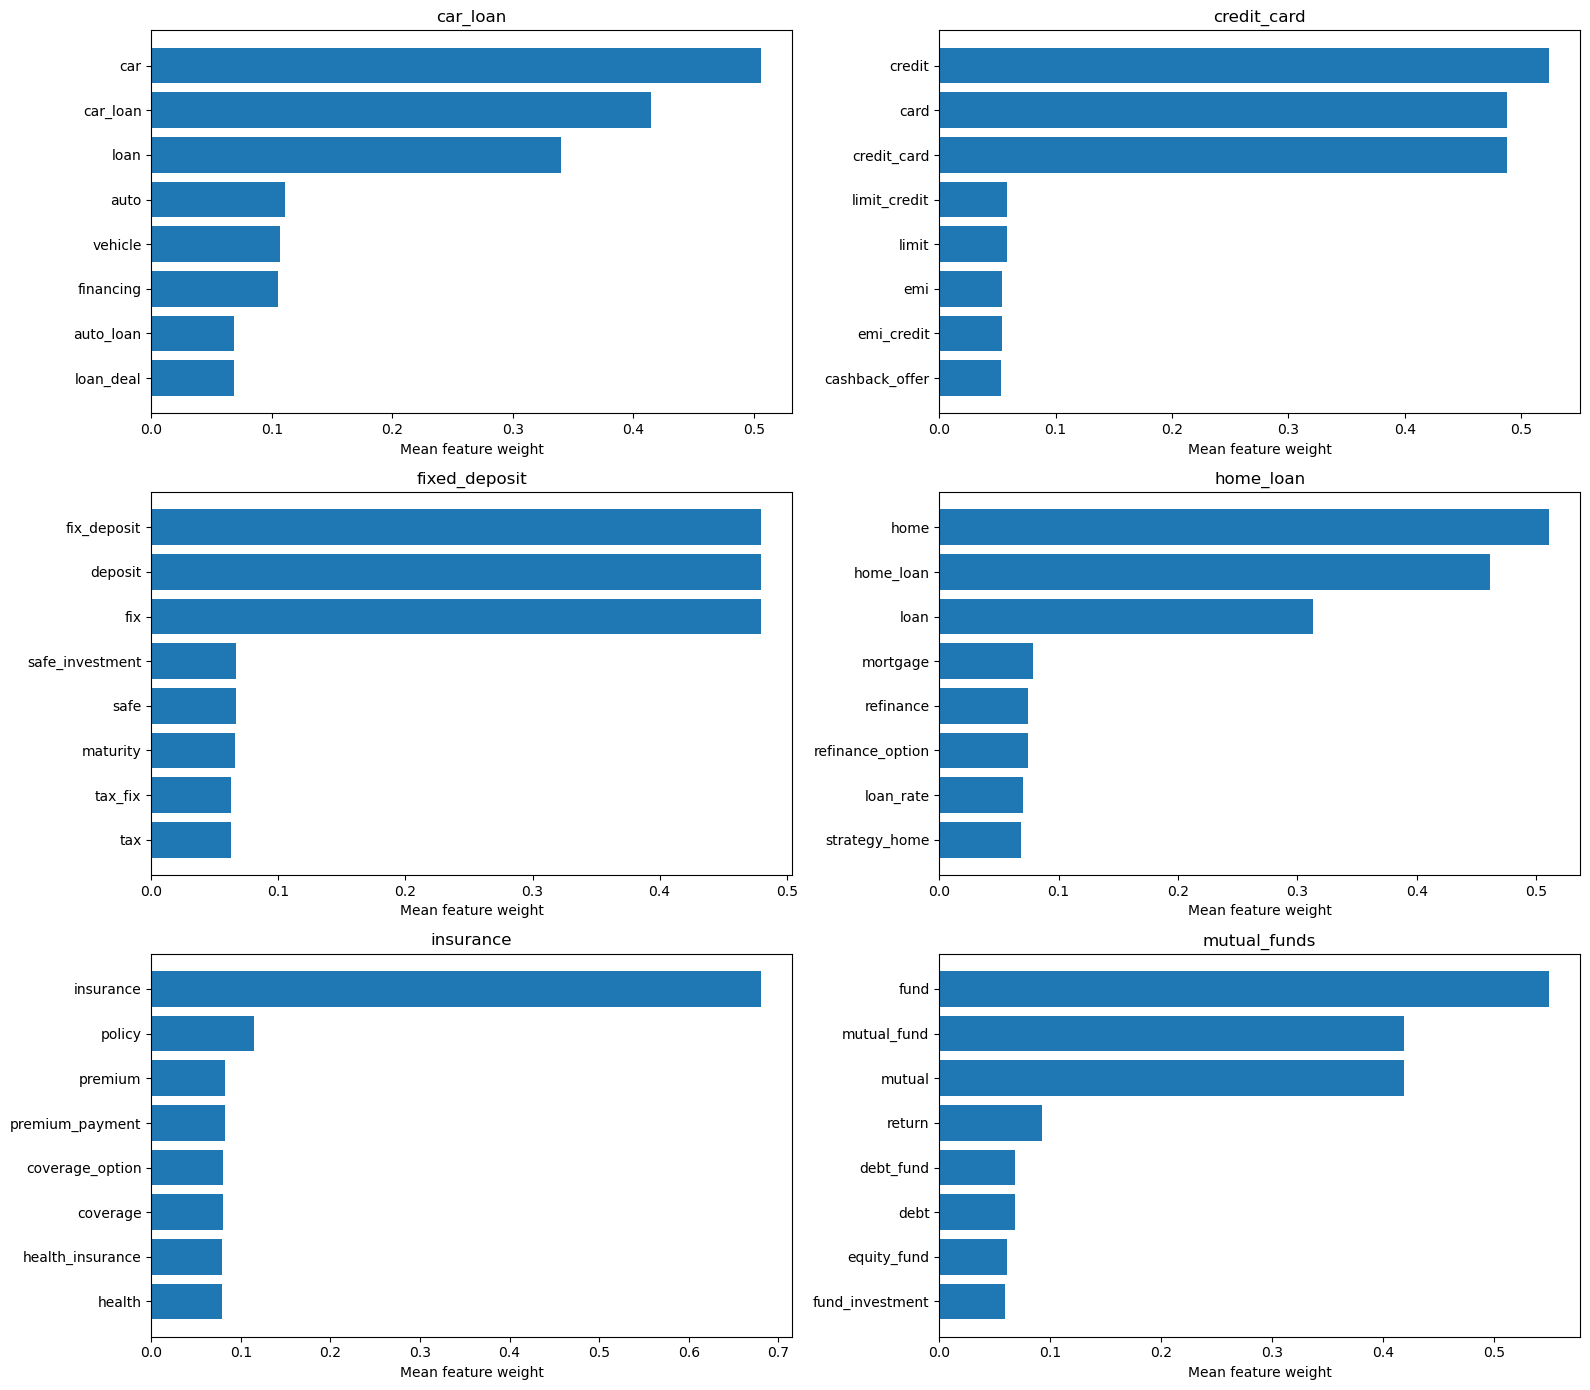

In [17]:

# Visualize top 8 n-grams per class
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, label in zip(axes, label_order):
    top_feats = class_ngram_means.loc[label].sort_values(ascending=False).head(8)
    feat_names = [f.replace('Preprocessed news.[', '').replace(']', '') for f in top_feats.index]
    ax.barh(feat_names[::-1], top_feats.values[::-1])
    ax.set_title(label)
    ax.set_xlabel('Mean feature weight')

plt.tight_layout()
plt.show()



### Why this matters

This is the main advantage of the **Extract N-Grams** pipeline:

- It tells you **which words and phrases define each news category**.
- That helps with explainability, content QA, labeling review, and stakeholder trust.
- The hashing pipeline cannot give you this kind of semantic feature story.


## 9) Lowest-confidence examples (useful for QA review)

In [18]:

review_cols = ['true_label', 'pred_ngram', 'pred_hash', 'max_prob_ngram', 'margin_ngram', 'news']
lowest_confidence_examples = combined.sort_values(['max_prob_ngram', 'margin_ngram']).loc[:, review_cols].head(10)
lowest_confidence_examples


,true_label,pred_ngram,pred_hash,max_prob_ngram,margin_ngram,news
1,credit_card,credit_card,credit_card,0.999997,0.999996,Recent developments in credit card interest ra...
2,car_loan,car_loan,car_loan,0.999997,0.999996,Analysts expect car loan approval to play a cr...
3,car_loan,car_loan,car_loan,0.999997,0.999996,Analysts expect auto financing to play a cruci...
6,car_loan,car_loan,car_loan,0.999997,0.999996,"According to recent reports, automobile market..."
11,car_loan,car_loan,car_loan,0.999997,0.999996,"Given the current trends in car purchase, many..."
12,car_loan,car_loan,car_loan,0.999997,0.999996,Financial experts suggest keeping an eye on th...
13,credit_card,credit_card,credit_card,0.999997,0.999996,Financial experts suggest keeping an eye on th...
15,car_loan,car_loan,car_loan,0.999997,0.999996,Customers are increasingly focused on loan ten...
17,car_loan,car_loan,car_loan,0.999997,0.999996,Recent developments in second-hand car financi...
21,car_loan,car_loan,car_loan,0.999997,0.999996,Analysts expect automobile market to play a cr...



### Why this matters

Even when a model scores perfectly, the *least confident* items are still the best place to start human QA:

- they reveal edge-case wording
- they help validate label quality
- they are the first candidates for future monitoring in production


## 10) Final business insights

In [19]:

insights = [
    f"Both feature pipelines scored the same {len(combined):,} articles and produced identical predictions on every row.",
    f"Both methods achieved {combined['correct_ngram'].mean():.2%} accuracy on this scored dataset, with perfectly balanced class counts across all six categories.",
    f"Average model confidence is extremely high for both methods (mean max probability ≈ {combined['max_prob_ngram'].mean():.6f}).",
    f"N-grams use {len(ngram_feature_cols)} interpretable features, while hashing uses {len(hash_feature_cols)} fixed buckets.",
    f"On average, each article activates about {combined['active_ngram_features'].mean():.1f} n-gram features versus {combined['active_hash_features'].mean():.1f} hashed features.",
    "Because outputs are identical, the choice between the two pipelines is mainly operational: use n-grams when explainability matters, and hashing when you want a fixed-size representation.",
    "The perfect score is a strength signal, but also a warning sign: validate on truly unseen articles to rule out easy separation, repetitive phrasing, or leakage."
]

for item in insights:
    display(Markdown(f'- {item}'))


- Both feature pipelines scored the same 1,500 articles and produced identical predictions on every row.

- Both methods achieved 100.00% accuracy on this scored dataset, with perfectly balanced class counts across all six categories.

- Average model confidence is extremely high for both methods (mean max probability ≈ 0.999997).

- N-grams use 693 interpretable features, while hashing uses 1024 fixed buckets.

- On average, each article activates about 36.7 n-gram features versus 106.6 hashed features.

- Because outputs are identical, the choice between the two pipelines is mainly operational: use n-grams when explainability matters, and hashing when you want a fixed-size representation.

- The perfect score is a strength signal, but also a warning sign: validate on truly unseen articles to rule out easy separation, repetitive phrasing, or leakage.


## Suggested business use

### Use the classifier for
- routing banking news into the correct content bucket
- powering topical dashboards by product line
- alerting business units when relevant category coverage spikes
- reducing manual tagging effort for operations or marketing teams
- creating downstream summaries per product category

### Use the n-gram pipeline when
- you need explainability for why an article was classified into a category
- you want to inspect the words and phrases driving each class
- stakeholders care about transparent feature logic

### Use the feature hashing pipeline when
- you want a fixed-width feature space for engineering simplicity
- you care more about compact representation than word-level explainability
- you are scaling to larger vocabularies and do not need direct term inspection



## Bottom line

On this scored dataset, **both pipelines are functionally equivalent in output**. The real differentiator is not classification quality here — it is **interpretability**.

- **Extract N-Grams** is better for explainable reporting and business review.
- **Feature Hashing** is better for compact, engineering-friendly feature handling.

If this notebook is being used for a report or presentation, the strongest message is:

> *Both text feature engineering approaches achieved identical classification performance, but extract n-grams provides clearer semantic interpretability, making it more suitable for business-facing analytics and model explanation.*
